<a href="https://colab.research.google.com/github/sineth-04/gen-ai-projects/blob/main/gan/gan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adding all libraries needed for classic GAN model (Trained using MNIST numbers dataset)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt

In [2]:
# Load MNIST handwritten digits
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

print(f"Dataset loaded! {len(dataset)} images")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.54MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.92MB/s]

Dataset loaded! 60000 images


Building the Generator (forger of images): This network takes 100 random numbers as input and transforms them through layers until it spits out a 28x28 image.

In [3]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 784),  # 28x28 image
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1, 28, 28)

Building the Discriminator (the Detective): It gets shown real MNIST digits and fake ones from the Generator, and has to learn to tell them apart.

In [4]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()  # outputs 0 (fake) or 1 (real)
        )

    def forward(self, x):
        return self.model(x.view(-1, 784))

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize networks
generator = Generator().to(device)
discriminator = Discriminator().to(device)

# Loss and optimizers
criterion = nn.BCELoss()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)

print("Generator and Discriminator ready!")
print(f"Training on: {device}")

Generator and Discriminator ready!
Training on: cuda


Epoch 1/50 | D Loss: 0.4787 | G Loss: 5.0192
Epoch 2/50 | D Loss: 0.5101 | G Loss: 4.3223
Epoch 3/50 | D Loss: 0.7182 | G Loss: 5.3158
Epoch 4/50 | D Loss: 0.1243 | G Loss: 5.3306
Epoch 5/50 | D Loss: 0.3818 | G Loss: 6.0913
Epoch 6/50 | D Loss: 0.2345 | G Loss: 4.5404
Epoch 7/50 | D Loss: 0.1221 | G Loss: 5.0995
Epoch 8/50 | D Loss: 0.1831 | G Loss: 11.5224
Epoch 9/50 | D Loss: 0.2032 | G Loss: 5.5185
Epoch 10/50 | D Loss: 0.2841 | G Loss: 4.8409


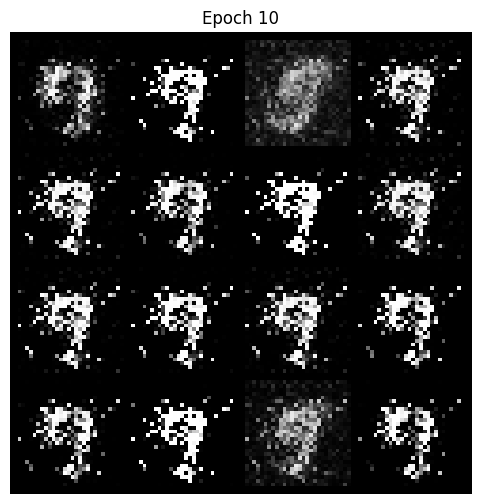

Epoch 11/50 | D Loss: 0.1108 | G Loss: 7.5713
Epoch 12/50 | D Loss: 0.2433 | G Loss: 8.7328
Epoch 13/50 | D Loss: 0.3833 | G Loss: 2.6002
Epoch 14/50 | D Loss: 0.1405 | G Loss: 5.1176
Epoch 15/50 | D Loss: 0.3274 | G Loss: 4.6004
Epoch 16/50 | D Loss: 0.3164 | G Loss: 4.7125
Epoch 17/50 | D Loss: 0.2921 | G Loss: 3.7316
Epoch 18/50 | D Loss: 0.3532 | G Loss: 4.4521
Epoch 19/50 | D Loss: 0.1753 | G Loss: 5.0098
Epoch 20/50 | D Loss: 0.2147 | G Loss: 4.5308


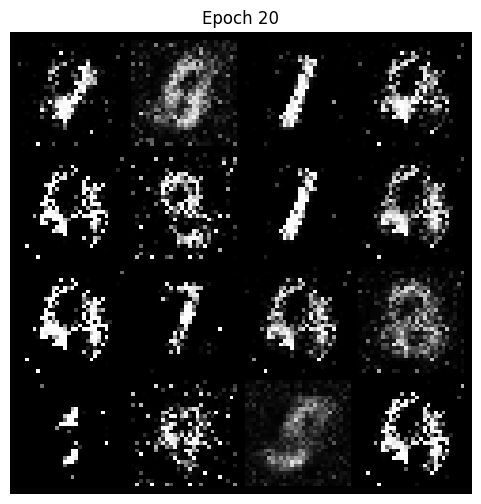

Epoch 21/50 | D Loss: 0.2839 | G Loss: 4.7370
Epoch 22/50 | D Loss: 0.2690 | G Loss: 2.7493
Epoch 23/50 | D Loss: 0.3088 | G Loss: 4.5986
Epoch 24/50 | D Loss: 0.3084 | G Loss: 2.8330
Epoch 25/50 | D Loss: 0.1996 | G Loss: 4.1310
Epoch 26/50 | D Loss: 0.1777 | G Loss: 3.9318
Epoch 27/50 | D Loss: 0.5336 | G Loss: 3.8726
Epoch 28/50 | D Loss: 0.1671 | G Loss: 4.7328
Epoch 29/50 | D Loss: 0.3116 | G Loss: 3.9002
Epoch 30/50 | D Loss: 0.5106 | G Loss: 2.5168


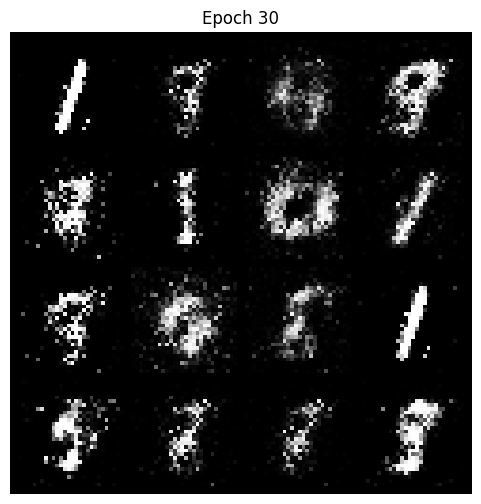

Epoch 31/50 | D Loss: 0.2538 | G Loss: 4.5174
Epoch 32/50 | D Loss: 0.5419 | G Loss: 3.0369
Epoch 33/50 | D Loss: 0.2510 | G Loss: 4.4315
Epoch 34/50 | D Loss: 0.2877 | G Loss: 3.4283
Epoch 35/50 | D Loss: 0.3232 | G Loss: 3.0386
Epoch 36/50 | D Loss: 0.5644 | G Loss: 3.6643
Epoch 37/50 | D Loss: 0.4645 | G Loss: 2.7283
Epoch 38/50 | D Loss: 0.4994 | G Loss: 3.3466
Epoch 39/50 | D Loss: 0.4371 | G Loss: 2.7763
Epoch 40/50 | D Loss: 0.5982 | G Loss: 2.3015


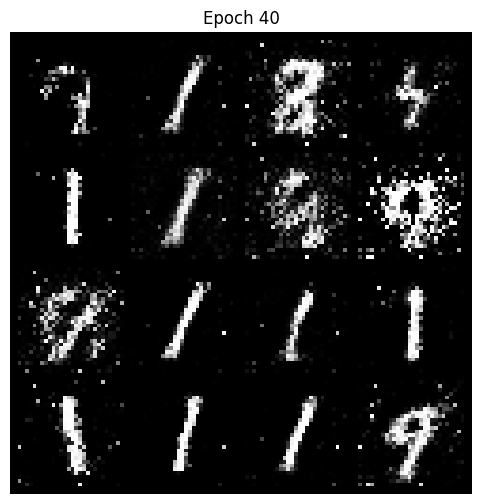

Epoch 41/50 | D Loss: 0.4427 | G Loss: 2.8666
Epoch 42/50 | D Loss: 0.6019 | G Loss: 2.7629
Epoch 43/50 | D Loss: 0.2717 | G Loss: 3.2850
Epoch 44/50 | D Loss: 0.5483 | G Loss: 3.0704
Epoch 45/50 | D Loss: 0.5288 | G Loss: 1.9302
Epoch 46/50 | D Loss: 0.6711 | G Loss: 2.5618
Epoch 47/50 | D Loss: 0.4160 | G Loss: 3.0209
Epoch 48/50 | D Loss: 0.5456 | G Loss: 2.8026
Epoch 49/50 | D Loss: 0.3842 | G Loss: 2.4798
Epoch 50/50 | D Loss: 0.7119 | G Loss: 2.2411


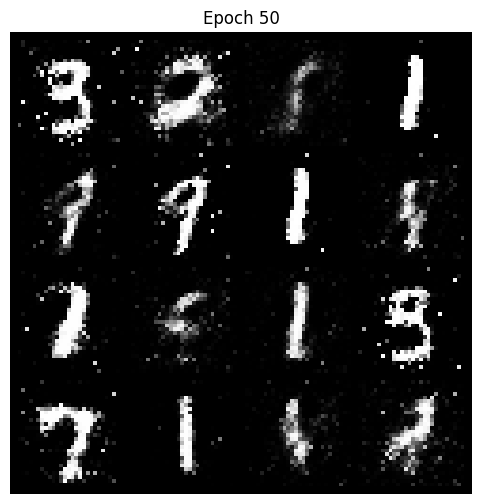

In [7]:
def show_images(generator, epoch):
    generator.eval()
    with torch.no_grad():
        noise = torch.randn(16, 100).to(device)
        fake_images = generator(noise)
        grid = make_grid(fake_images, nrow=4, normalize=True)
        plt.figure(figsize=(6,6))
        plt.imshow(grid.permute(1,2,0).cpu(), cmap="gray")
        plt.title(f"Epoch {epoch}")
        plt.axis("off")
        plt.show()
    generator.train()

# Train!
epochs = 50
for epoch in range(epochs):
    for real_images, _ in dataloader:
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        # Train Discriminator
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        d_optimizer.zero_grad()
        real_loss = criterion(discriminator(real_images), real_labels)
        noise = torch.randn(batch_size, 100).to(device)
        fake_images = generator(noise)
        fake_loss = criterion(discriminator(fake_images.detach()), fake_labels)
        d_loss = real_loss + fake_loss
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        g_optimizer.zero_grad()
        g_loss = criterion(discriminator(fake_images), real_labels)
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

    # Show images every 10 epochs
    if (epoch + 1) % 10 == 0:
        show_images(generator, epoch + 1)